In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Analyse the correlation b/w the performance of the networks with different weights and different memory capacity measurements

In [3]:
import wandb

api = wandb.Api()

!export WANDB_API_KEY=d40292fde8c59aa4440c
# %env WANDB_API_KEY=YOUR_NEW_KEY

wandb.login()

wandb: Currently logged in as: lilly-reisig (xiaoxionglin-bernstein-center-freiburg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
runs = api.runs("xiaoxionglin-bernstein-center-freiburg/SF_dmlab_esn_different_weights_44")
all_results=dict()

In [5]:
# TODO create a framework before that makes it easy to differentiate b/w the different seeds

# len(weights) = 34
n_seeds = 3

In [12]:
for i, run in enumerate(runs):
    print(i, run.config['weight_trial'])
    print(i+1)
    print((i+1)%n_seeds)
    if (i+1)%n_seeds == 0:
        print('next weight trial')

0 1
1
1
1 1
2
2
2 1
3
0
next weight trial
3 3
4
1
4 3
5
2
5 3
6
0
next weight trial
6 4
7
1
7 4
8
2
8 4
9
0
next weight trial
9 5
10
1
10 5
11
2
11 5
12
0
next weight trial
12 6
13
1
13 6
14
2
14 6
15
0
next weight trial
15 7
16
1
16 7
17
2
17 7
18
0
next weight trial
18 8
19
1
19 8
20
2
20 8
21
0
next weight trial
21 9
22
1
22 9
23
2
23 9
24
0
next weight trial
24 11
25
1
25 11
26
2
26 11
27
0
next weight trial
27 12
28
1
28 12
29
2
29 12
30
0
next weight trial
30 13
31
1
31 13
32
2
32 13
33
0
next weight trial
33 14
34
1
34 14
35
2
35 14
36
0
next weight trial
36 15
37
1
37 15
38
2
38 15
39
0
next weight trial
39 17
40
1
40 17
41
2
41 17
42
0
next weight trial
42 18
43
1
43 18
44
2
44 18
45
0
next weight trial
45 22
46
1
46 22
47
2
47 22
48
0
next weight trial
48 23
49
1
49 23
50
2
50 23
51
0
next weight trial
51 24
52
1
52 24
53
2
53 24
54
0
next weight trial
54 27
55
1
55 27
56
2
56 27
57
0
next weight trial
57 28
58
1
58 28
59
2
59 28
60
0
next weight trial
60 29
61
1
61 29
62
2
6

In [ ]:
dfs = []
regex = r'raw|reward_min$|len/len$|lenweighted_score$|global_step$'
n_categories = regex.count('|') + 1
n_policies = 4

runs = sorted(runs, key=lambda run: run.config['weight_trial'])

for idx, run in enumerate(runs):
    print(idx, run.config['weight_trial'])
    # extract the relevant data for this run, and store it in the corresponding weight trial dataframe
    weight_trial = run.config['weight_trial']
    cols = pd.Series(run.summary.keys())
    filtered = cols[cols.str.contains(regex, regex=True)].tolist()  # list of metric keys ordered by policy

    for j in range(1, n_categories):
        for i in range(n_policies):
            tmpdf2 = run.history(keys=filtered[i*n_categories:i*n_categories+j+1:j],samples=100000,pandas=True)  # time series of the selected metrics
            tmpdf=tmpdf2.groupby(tmpdf2[filtered[i*n_categories]].apply(lambda x: 30000*(x//30000)))[filtered[i*n_categories+j]].mean().reset_index(name=filtered[i*n_categories+j])  # smooth and time bin tmpdf2
            # format of tmpdf: binned global step | mean metric value
            dfs.append(tmpdf)
            #print(dfs)

    # after all seeds for a given weight trial have been processed, process their dataframe and add it to the overall dictionary
    if (idx+1)%n_seeds == 0:
        print(f"Processing weight trial {weight_trial}...")
        #print(dfs)
        #result = pd.concat([df.set_index(df.columns[0]) for df in dfs],axis=1)
        #dfs_by_policy = {p: result.loc[:, result.columns.str.startswith(f"{p}/")].copy() for p in range(4)}
        #df0, df1, df2, df3 = (dfs_by_policy[p] for p in range(4))

        dfs_by_policy = dict()
        for p in range(n_policies):
            parts = []
            #idx_col = f"{p}/global_step"
            index_column = dfs[p][f"{p}/global_step"] 
            parts.append(index_column)
            for df in dfs:
                cols = [c for c in df.columns if c.startswith(f"{p}/")]# and c != idx_col]
                if not cols:
                    continue
                #d = df.set_index(df.columns[0])[cols].copy()
                #print(cols)

                parts.append(df[cols[1]])
            dfs_by_policy[p] = pd.concat(parts, axis=1)
        break

0 1
1 1
2 1
Processing weight trial 1...
['0/global_step', '0/len/len']
['0/global_step', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score']
['0/global_step', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score']
['0/global_step', '0/reward/reward_min']
['0/global_step', '0/len/len']
['0/global_step', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score']
['0/global_step', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score']
['0/global_step', '0/reward/reward_min']
['0/global_step', '0/len/len']
['0/global_step', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score']
['0/global_step', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score']
['0/global_step', '0/reward/reward_min']
['1/global_step', '1/len/len']
['1/global_step', '1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score']
['1/global_step', '1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score']
['1/glob

In [72]:

print(dfs_by_policy[2])

      2/global_step    2/len/len  \
0          840000.0  6615.560000   
1          870000.0  6713.800000   
2          900000.0  6730.040000   
3          930000.0  6790.200000   
4          960000.0  6850.640000   
...             ...          ...   
4548    144870000.0  2347.860000   
4549    144900000.0  2328.864000   
4550    144930000.0  2221.552000   
4551    144960000.0  2342.866667   
4552    144990000.0  2450.900000   

      2/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score  \
0                                                  0.35                   
1                                                  0.30                   
2                                                  0.40                   
3                                                  0.40                   
4                                                  0.40                   
...                                                 ...                   
4548                                      

In [19]:
dfs = []
regex = r'raw|reward_min$|len/len$|lenweighted_score$|global_step$'
n_categories = regex.count('|') + 1
n_policies = 4

runs = sorted(runs, key=lambda run: run.config['weight_trial'])

for idx, run in enumerate(runs):
    print(idx, run.config['weight_trial'])
    # extract the relevant data for this run, and store it in the corresponding weight trial dataframe
    weight_trial = run.config['weight_trial']
    cols = pd.Series(run.summary.keys())
    filtered = cols[cols.str.contains(regex, regex=True)].tolist()  # list of metric keys ordered by policy

    for j in range(1, n_categories):
        for i in range(n_policies):
            tmpdf2 = run.history(keys=filtered[i*n_categories:i*n_categories+j+1:j],samples=100000,pandas=True)  # time series of the selected metrics
            tmpdf=tmpdf2.groupby(tmpdf2[filtered[i*n_categories]].apply(lambda x: 30000*(x//30000)))[filtered[i*n_categories+j]].mean().reset_index(name=filtered[i*n_categories+j])  # smooth and time bin tmpdf2
            # format of tmpdf: binned global step | mean metric value
            dfs.append(tmpdf)
            #print(dfs)

    # after all seeds for a given weight trial have been processed, process their dataframe and add it to the overall dictionary
    if (idx+1)%n_seeds == 0:
        print(f"Processing weight trial {weight_trial}...")
        print(dfs)
        # make the first column of the dataframes the index (binned global step)
        for df in dfs:
            df.set_index(df.columns[0], inplace=True, drop=True)

        # build a common time axis, that aligns all dataframes in dfs
        # union_idx contains all indices that appear in any of the dataframes in dfs
        union_idx = dfs[0].index # initilize union with the index of the first df
        for df in dfs[1:]:
            union_idx = union_idx.union(df.index)

        # 3) Reindex + interpolate each DataFrame
        # make sure all metrics are on a shared time axis, & metrics have values at every step of union_idx (interpolate their values there)
        aligned = []
        for df in dfs:
            # Reindex to the full union (creates NaNs where missing), every df now has the union_idx as index
            df2 = df.reindex(union_idx)
            # Interpolate numeric columns along the index, interpolate the values where NaNs were created by reindexing
            df2_interp = df2.interpolate(method='index', limit_direction='both')
            aligned.append(df2_interp)

        # Now every df in `aligned` has the same index = union_idx, with NaNs filled.
        # You can concat or merge them directly:
        result = pd.concat(aligned, axis=1)

        all_results[weight_trial] = result
        dfs = []



        

0 1
1 1
2 1
Processing weight trial 1...
[      0/global_step    0/len/len
0          930000.0  6463.260000
1          990000.0  6600.420000
2         1020000.0  6719.720000
3         1050000.0  6790.120000
4         1080000.0  6817.000000
...             ...          ...
4821    154680000.0  2451.213333
4822    154710000.0  2317.520000
4823    154740000.0  2329.140000
4824    154770000.0  2357.472000
4825    154800000.0  2467.613333

[4826 rows x 2 columns],       1/global_step    1/len/len
0          990000.0  6338.480000
1         1020000.0  6358.960000
2         1050000.0  6389.680000
3         1080000.0  6397.360000
4         1110000.0  6457.520000
...             ...          ...
4777    151530000.0  3683.080000
4778    151560000.0  3667.746667
4779    151590000.0  3532.880000
4780    151620000.0  3523.360000
4781    151650000.0  3544.760000

[4782 rows x 2 columns],       2/global_step    2/len/len
0          840000.0  6615.560000
1          870000.0  6713.800000
2          9000

KeyboardInterrupt: 

In [17]:
print(all_results)

{1:                0/len/len  1/len/len  2/len/len  3/len/len  \
780000.0     6463.260000    6338.48    6615.56   6168.960   
810000.0     6463.260000    6338.48    6615.56   6168.960   
840000.0     6463.260000    6338.48    6615.56   6201.920   
870000.0     6463.260000    6338.48    6713.80   6318.120   
900000.0     6463.260000    6338.48    6730.04   6413.520   
...                  ...        ...        ...        ...   
157350000.0  2467.613333    3544.76    2450.90   3307.624   
157380000.0  2467.613333    3544.76    2450.90   3193.600   
157410000.0  2467.613333    3544.76    2450.90   3102.140   
157440000.0  2467.613333    3544.76    2450.90   3020.240   
157470000.0  2467.613333    3544.76    2450.90   2976.040   

             0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score  \
780000.0                                                  0.45                   
810000.0                                                  0.45                   
840000.0         

In [8]:
dfs = []
regex = r'raw|reward_min$|len/len$|lenweighted_score$|global_step$'
n_categories = regex.count('|') + 1
n_policies = 4


for run in runs:
    cols = pd.Series(run.summary.keys())
    filtered = cols[cols.str.contains(regex, regex=True)].tolist()  # list of metric keys ordered by policy
    print(filtered)

    for j in range(1, n_categories):
        for i in range(n_policies):
            tmpdf2 = run.history(keys=filtered[i*n_categories:i*n_categories+j+1:j],samples=100000,pandas=True)  # time series of the selected metrics
            tmpdf=tmpdf2.groupby(tmpdf2[filtered[i*n_categories]].apply(lambda x: 30000*(x//30000)))[filtered[i*n_categories+j]].mean().reset_index(name=filtered[i*n_categories+j])  # smooth and time bin tmpdf2
            # format of tmpdf: binned global step | mean metric value
            dfs.append(tmpdf)
    
# make the first column of the dataframes the index (binned global step)
for df in dfs:
    df.set_index(df.columns[0], inplace=True, drop=True)

# build a common time axis, that aligns all dataframes in dfs
# union_idx contains all indices that appear in any of the dataframes in dfs
union_idx = dfs[0].index # initilize union with the index of the first df
for df in dfs[1:]:
    union_idx = union_idx.union(df.index)

# 3) Reindex + interpolate each DataFrame
# make sure all metrics are on a shared time axis, & metrics have values at every step of union_idx (interpolate their values there)
aligned = []
for df in dfs:
    # Reindex to the full union (creates NaNs where missing), every df now has the union_idx as index
    df2 = df.reindex(union_idx)
    # Interpolate numeric columns along the index, interpolate the values where NaNs were created by reindexing
    df2_interp = df2.interpolate(method='index', limit_direction='both')
    aligned.append(df2_interp)

# Now every df in `aligned` has the same index = union_idx, with NaNs filled.
# You can concat or merge them directly:
result = pd.concat(aligned, axis=1)


# TODO integrate this part for cases where we have multiple weight trials or spectral radii etc
# all_results[f"{DG_code[i_dense]}_{core_code[i_archi]}"] = result



['0/global_step', '0/len/len', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score', '0/reward/reward_min', '1/global_step', '1/len/len', '1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score', '1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score', '1/reward/reward_min', '2/global_step', '2/len/len', '2/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score', '2/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score', '2/reward/reward_min', '3/global_step', '3/len/len', '3/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score', '3/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score', '3/reward/reward_min']
['0/global_step', '0/len/len', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score', '0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score', '0/reward/reward_min', '1/global_step', '1/len/len', '1/

KeyboardInterrupt: 

In [15]:
print(dfs)

[      0/global_step    0/len/len
0          810000.0  6389.640000
1          840000.0  6500.160000
2          870000.0  6541.120000
3          900000.0  6574.760000
4          930000.0  6654.120000
...             ...          ...
4567    143850000.0  3692.426667
4568    143880000.0  3766.640000
4569    143910000.0  3757.560000
4570    143940000.0  3818.340000
4571    143970000.0  3720.760000

[4572 rows x 2 columns],       1/global_step  1/len/len
0          870000.0    6310.94
1          900000.0    6398.80
2          930000.0    6415.44
3          960000.0    6578.40
4          990000.0    6660.32
...             ...        ...
5691    187140000.0    3724.26
5692    187170000.0    3565.82
5693    187200000.0    3573.36
5694    187230000.0    3683.66
5695    187260000.0    3672.76

[5696 rows x 2 columns],       2/global_step    2/len/len
0          930000.0  6366.120000
1          960000.0  6435.160000
2          990000.0  6522.720000
3         1020000.0  6531.680000
4         1050

0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
2/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
3/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
2/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
3/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
0/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
1/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
2/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score
3/policy_stats/avg_z_00_openfield_map2_fixed_loc3_lenweighted_score


Text(0.5, 1.0, 'Length Weighted Score over Global Steps for Different Policies')

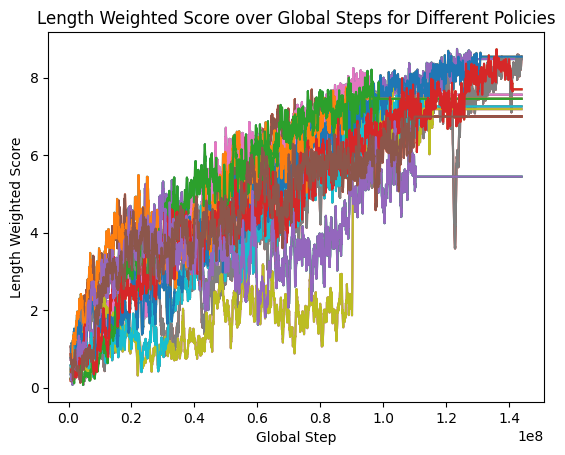

In [ ]:
# try out the unfiltered plotting with no gaussian smoothing, only the mean over bins

columns_to_plot = 'lenweighted_score'
filtered_columns = [c for c in result.columns if columns_to_plot in c]

plt.figure()
for col in filtered_columns:
    #print(col)
    plt.plot(result.index, result[col], label=col)

plt.xlabel('Global Step')
plt.ylabel('Length Weighted Score')
plt.title('Length Weighted Score over Global Steps for Different Policies')
#plt.legend()